In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os
from scipy.optimize import curve_fit
import sympy
from processing import filter_region, sort_max_arr, remove_rate
from visualizations import lineplots_4x4, smooth_func
from datetime import datetime
import glasbey

# load prediction arrays, create array objects

In [3]:
folder_path = 'predictions/8-27-2025/'

In [4]:
folders = [folder for folder in os.listdir(folder_path)]
print('len of folders: ', len(folders))

len of folders:  110


In [5]:
test_sum = np.load(f'{folder_path}image0/sum_arr_image0.npy')
print('test_sum shape: ', test_sum.shape)

test_sum shape:  (1, 100, 7493)


In [6]:
def load_arrs(arr_type: str):
    if arr_type not in ['sum', 'mean', 'var', 'label']: raise ValueError ('---Insert "sum" or "mean" "var" or "label" as input---')
    return_arr = np.empty((110, 100, 7493)) if arr_type == 'sum' else np.empty((110, 7493))
    for arr_index in range(110):
        arr_temp = np.load(f'{folder_path}image{arr_index}/{arr_type}_arr_image{arr_index}.npy')
        return_arr[arr_index] = arr_temp
    return return_arr

In [7]:
sum_arr = load_arrs('sum')
mean_arr = load_arrs('mean')
var_arr = load_arrs('var')
label_arr = load_arrs('label')

In [8]:
print(f'sum shape: {sum_arr.shape}; mean shape: {mean_arr.shape}; var shape: {var_arr.shape}')

sum shape: (110, 100, 7493); mean shape: (110, 7493); var shape: (110, 7493)


In [9]:
np.unique(mean_arr == var_arr, return_counts = True) # ensure we are returning different arrays

(array([False]), array([824230]))

# get mean and var arrays from V1
filtering done as well

get region 1 here

In [10]:
mean_v1 = filter_region(1, label_arr, mean_arr)
var_v1 = filter_region(1, label_arr, var_arr)

In [11]:
print(f'mean shape: {mean_v1.shape}, var shape: {var_v1.shape}')

mean shape: (110, 5312), var shape: (110, 5312)


### remove anything above 200 spikes/sec

In [11]:
mean_v1_removed = remove_rate(mean_v1, 200)

In [12]:
print('mean shape:', mean_v1_removed.shape)

mean shape: (110, 5312)


In [13]:
np.unique(np.isnan(mean_v1_removed), return_counts = True)

(array([False,  True]), array([582882,   1438]))

In [14]:
var_v1_removed = np.where(np.isnan(mean_v1_removed), mean_v1_removed, var_v1)

In [15]:
print('var shape:', var_v1_removed.shape)

var shape: (110, 5312)


In [16]:
np.unique(np.isnan(var_v1_removed), return_counts = True)

(array([False,  True]), array([582882,   1438]))

In [17]:
test_neuron = 250

In [18]:
mean_v1_removed[..., test_neuron]

array([ 1.2463064 ,  1.24020794,  1.25462661,  1.24655529,  1.2425826 ,
        1.25153601,  1.2398717 ,  1.24163726,  1.2480869 ,  1.24156901,
        6.37779003,  2.54841062,  0.90853661,  4.65332162,  2.21029007,
        1.35951157,  6.54871568,  1.36838745,  0.90229548,  3.83509161,
        3.83487322,  1.35078649,  3.32662263,  8.25588995,  6.0524421 ,
        3.22314709,  1.72692854,  3.21568874, 21.89021402,  1.2630467 ,
        1.63322649,  5.63047903,  5.40039839,  3.32853719, 15.53215022,
        3.39507595,  0.62955402,  6.13283806, 10.41562607,  2.61652664,
        1.27100447,  9.6138177 ,  4.62776532, 13.49668428,  2.41314971,
        3.00902056,  5.39590202,  3.55865272,  6.25919223,  1.06665893,
        0.72649008,  3.1069436 ,  6.3636409 ,  2.24445013,  4.06503166,
        3.88841465,  3.19797114,  9.17677807, 17.50732809,  1.05598657,
        1.20878679,  1.27737361,  2.52204806,  1.12632903,  1.30531135,
        1.08834569, 18.82170198,  1.74326626,  4.27722898,  2.21

In [19]:
var_v1_removed[..., test_neuron]

array([5.89519778e-03, 6.25225449e-03, 5.64696894e-03, 7.58986399e-03,
       8.44021462e-03, 8.26533545e-03, 6.82200535e-03, 6.09422311e-03,
       5.67081193e-03, 1.00324913e-02, 2.23116135e-01, 4.72871449e-02,
       1.70939150e-03, 1.10786283e-01, 3.36602995e-02, 8.61004195e-03,
       2.18050575e-01, 1.12997696e-02, 4.55823124e-03, 5.70135352e-02,
       7.09870565e-02, 5.83171457e-03, 9.25808855e-02, 7.42191340e-01,
       2.33131671e-01, 5.28287135e-02, 9.60795727e-03, 9.09330979e-02,
       4.70275761e+00, 8.48655071e-03, 1.77596737e-02, 2.08138842e-01,
       1.34898624e-01, 4.03271419e-02, 2.13739022e+00, 8.47248433e-02,
       1.00310265e-03, 3.02719337e-01, 7.41405904e-01, 4.72942837e-02,
       5.21759589e-03, 5.27805192e-01, 1.62557925e-01, 1.02839045e+00,
       2.79139484e-02, 7.82202498e-02, 1.49322907e-01, 1.14970853e-01,
       3.52514036e-01, 5.78027666e-03, 6.37661664e-04, 5.82232829e-02,
       2.63737339e-01, 1.67510495e-02, 1.01280631e-01, 1.08535081e-01,
      

### get indices to sort

In [12]:
print(f'unique counts for mean_arr:', np.unique(np.isnan(mean_v1_removed), return_counts = True))
print(f'unique counts for var_arr:', np.unique(np.isnan(var_v1_removed), return_counts = True))
print('ensure that we have the same counts for both arrays')

NameError: name 'mean_v1_removed' is not defined

In [13]:
# run this when wanting to use array with removed values
max_arr = np.nanmax(mean_v1_removed, axis = 0)
max_arr.shape

NameError: name 'mean_v1_removed' is not defined

In [14]:
# run this when wanting to use array WITHOUT removed values
max_arr = np.nanmax(mean_v1, axis = 0)
max_arr.shape

(5312,)

In [15]:
for max_num in max_arr: print(max_num)

18.20643789894879
6.871708573102951
18.54305610060692
65.1902556309104
19.2026533728838
15.230209202766419
39.336862547397615
60.866338631510736
24.836072195768356
17.975822390019893
30.195233067274092
63.22873750656843
101.03568201422691
83.30904997348786
59.56254869401455
24.6268798533082
141.68977163910867
32.41425412416458
30.576551679372788
10.919594417065381
46.26562501847744
141.149938262105
24.8718533847481
47.67963366419077
30.58293590322137
25.131206027269364
20.26397334419191
11.6168127271533
26.99751196742058
11.24400021135807
28.633289091289043
13.28748903721571
55.28955410152674
27.113712515234948
39.34162843197584
20.99816920876503
14.628332357406617
32.82596981823444
42.36594277203083
25.944959621429444
74.61379934772849
20.55546413719654
31.60792947024107
56.76102456122637
23.22874755144119
22.558681053519248
95.17302981883287
20.167560538724064
25.838633379340173
23.257161124646665
125.54114495515823
48.55731274276972
36.56576255649328
35.096241635978224
57.4356507651

In [16]:
sort_indices = np.argsort(max_arr)[::-1]

In [17]:
len(sort_indices)

5312

In [18]:
# use this for when we remove above x rate
mean_v1_sorted = mean_v1_removed[..., sort_indices]
var_v1_sorted = var_v1_removed[..., sort_indices]

NameError: name 'mean_v1_removed' is not defined

In [19]:
# use this OTHERWISE
mean_v1_sorted = mean_v1[..., sort_indices]
var_v1_sorted = var_v1[..., sort_indices]

In [20]:
for neuron in range(mean_v1_sorted.shape[1]):
    print(np.nanmax(mean_v1_sorted[..., neuron]))

3219.628265551031
2205.0910019254684
1756.1778079247474
946.5949171978235
919.5072154802084
795.7486869654059
559.6811847287416
449.26452337831256
443.07451611965894
401.21435782194135
394.959543453753
381.4257377040386
379.152290430665
377.7355443429947
377.2417575061321
369.67155718445775
368.1748134639859
355.5115613615513
351.34153186708687
336.1826987761259
334.90840858727694
330.9552036085725
323.62320538133383
314.5612802773714
311.9416994965076
306.9855700045824
303.7958125053346
298.11114236712456
295.5415191605687
294.454366748333
291.81919581621884
289.6183042001724
289.59264233112333
289.5339551100135
289.11602999120953
288.9051912485063
287.8297334891558
283.29077895879743
280.7739016973972
279.5946013718843
277.47262667655946
277.20082801520823
276.64743771970274
271.91989620774984
269.9984476697445
268.36041808009145
268.1808758404851
266.42582656919956
265.6722914946079
261.6749886977673
261.03274709761143
259.5405519592762
259.49670186445115
259.35603589594365
258.0334

In [21]:
for neuron in range(mean_v1_sorted.shape[1]):
    print(np.max(mean_v1_sorted[..., neuron]))

3219.628265551031
2205.0910019254684
1756.1778079247474
946.5949171978235
919.5072154802084
795.7486869654059
559.6811847287416
449.26452337831256
443.07451611965894
401.21435782194135
394.959543453753
381.4257377040386
379.152290430665
377.7355443429947
377.2417575061321
369.67155718445775
368.1748134639859
355.5115613615513
351.34153186708687
336.1826987761259
334.90840858727694
330.9552036085725
323.62320538133383
314.5612802773714
311.9416994965076
306.9855700045824
303.7958125053346
298.11114236712456
295.5415191605687
294.454366748333
291.81919581621884
289.6183042001724
289.59264233112333
289.5339551100135
289.11602999120953
288.9051912485063
287.8297334891558
283.29077895879743
280.7739016973972
279.5946013718843
277.47262667655946
277.20082801520823
276.64743771970274
271.91989620774984
269.9984476697445
268.36041808009145
268.1808758404851
266.42582656919956
265.6722914946079
261.6749886977673
261.03274709761143
259.5405519592762
259.49670186445115
259.35603589594365
258.0334

#### *note that this code works and has been checked properly up to here*

In [ ]:
mean_v1_sorted[...,110]

array([  6.64955373,   6.60552719,   6.60534616,   6.66882058,
         6.64824673,   6.63138484,   6.58559904,   6.60979397,
         6.58199306,   6.58163665,  21.4886991 ,   2.54192298,
         9.52911187,  28.46254492,   5.93352338,  11.00911984,
        31.29392124,   8.14336613,  10.80733198, 112.11393446,
         0.98146363,  13.24377762,  10.03732418,  22.38456672,
        16.93983641,  39.86523454,   8.95087571,  13.44082539,
         1.97128165,   7.46672152,  30.17704794, 102.40223358,
         4.82684543,   2.79523037,  11.34659842,  10.82790937,
         2.57148984,  19.03295147,  14.1006289 ,  10.18515598,
        20.6928329 , 153.94423488,  17.55546049,  21.63779533,
        16.53653452,   3.18449392,   2.61636222,   2.28171697,
        24.9597754 ,   3.47544953,   1.93460608,  26.44787617,
        35.20488545,   9.26150118,   9.04851697,  61.55545418,
        22.16609885,   8.81986721,  14.62170353,   7.13597959,
         6.31598249,   5.69722202,  28.77183586,   5.09

In [ ]:
var_v1_sorted[..., 110]

array([2.44264666e-01, 2.29492849e-01, 1.93106769e-01, 2.51998729e-01,
       2.41960461e-01, 2.41912643e-01, 2.00946106e-01, 2.14914471e-01,
       2.11135941e-01, 2.44900703e-01, 2.74026407e+00, 2.46341968e-02,
       2.99239076e-01, 5.73179971e+00, 1.82244039e-01, 8.33311159e-01,
       7.15613481e+00, 4.29298151e-01, 7.76332051e-01, 1.14117267e+02,
       5.15553297e-04, 1.05525082e+00, 5.28975928e-01, 2.80623973e+00,
       2.11713065e+00, 1.28071470e+01, 3.36898494e-01, 1.12515856e+00,
       9.04992106e-03, 2.27594901e-01, 7.76488884e+00, 6.89849817e+01,
       8.42850907e-02, 1.96286240e-02, 1.09628185e+00, 8.21918816e-01,
       1.39824130e-02, 2.08282241e+00, 1.17413217e+00, 6.01600176e-01,
       2.20659259e+00, 1.75880916e+02, 1.89242599e+00, 2.03413457e+00,
       1.94503590e+00, 2.45529919e-02, 6.29061285e-03, 1.12544560e-02,
       3.32778690e+00, 4.69042823e-02, 6.76009412e-03, 4.35975613e+00,
       1.06835797e+01, 4.49487610e-01, 4.52068074e-01, 2.65516905e+01,
      

c:\Users\joshf\OneDrive\GitHub\fnn-haefner\visualizations.py:780: RuntimeWarning: overflow encountered in exp
  return (m / b) * (np.log1p(np.exp(b * x)) - np.log(2) - (b * x) / 2)


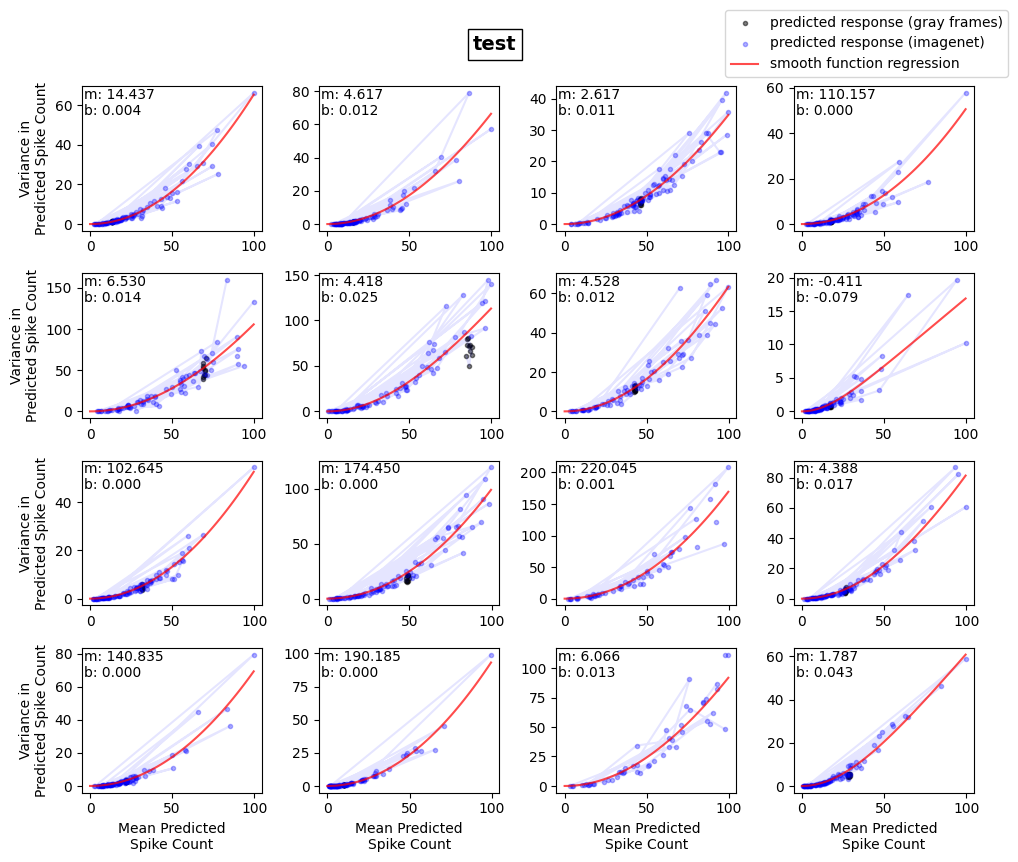

In [30]:
lineplots_4x4('test', [i for i in range(16)], mean_v1_sorted, var_v1_sorted)

# regression

In [31]:
test_neuron = 4508

test_means = mean_v1_sorted[..., test_neuron]
test_vars = var_v1_sorted[..., test_neuron]

In [32]:
from scipy.optimize import curve_fit
mask = ~np.isnan(test_means)
means_nonan = test_means[mask]
vars_nonan = test_vars[mask]

params, covariance = curve_fit(smooth_func, means_nonan, vars_nonan)

In [33]:
means_nonan

array([ 2.07157331,  2.06305897,  2.06925401,  2.07147122,  2.06530066,
        2.05380107,  2.06529609,  2.07663695,  2.07168157,  2.09127432,
        4.38843495,  1.29767069,  4.44433334,  3.42584599,  4.23352902,
        2.09183947,  0.83139352,  1.90767421,  1.60129324,  2.20123644,
        7.53177772,  4.78347987,  0.89892506,  0.76138383,  1.43846672,
        1.76056668,  8.33550391,  2.93630932,  1.12392856,  1.90869515,
        2.24922266,  5.7753997 ,  6.43420108,  4.46401592,  6.49514516,
        3.12384507,  2.3141734 ,  4.2183739 ,  6.99247767,  1.52144456,
        2.27661347,  0.88211372,  1.53712097,  3.38243198,  2.06321439,
        3.98172609, 13.99212207,  5.41750274,  1.04890757,  2.06841416,
        2.60778532,  3.68498946,  0.88763611,  2.52059799,  4.9745952 ,
        4.79130356,  3.75322263, 11.42748977,  0.77129392,  2.64548945,
        2.07967455,  2.83091768,  1.69514202,  2.71376208,  1.34258847,
        7.78475371,  0.64300645,  2.28543527,  1.73257452,  2.98

In [34]:
vars_nonan

array([9.59556972e-03, 7.79782187e-03, 1.12901959e-02, 9.03933382e-03,
       7.79733828e-03, 9.04397971e-03, 8.02150975e-03, 9.32840819e-03,
       1.19312824e-02, 9.20807639e-03, 6.52054447e-02, 4.93431269e-03,
       6.79053357e-02, 6.09648367e-02, 5.71325730e-02, 1.06216985e-02,
       1.57286934e-03, 8.11818797e-03, 6.82222741e-03, 1.47623599e-02,
       1.31812481e-01, 1.03374160e-01, 1.27141280e-03, 8.01899383e-04,
       9.08364221e-03, 1.00120077e-02, 2.43610129e-01, 2.80482312e-02,
       1.54494946e-03, 7.71006983e-03, 1.31840774e-02, 1.68116558e-01,
       1.94263349e-01, 4.31356613e-02, 1.18100020e-01, 2.85387174e-02,
       7.11977193e-03, 6.52410362e-02, 2.05099076e-01, 5.07045778e-03,
       1.52735479e-02, 1.57472681e-03, 5.73416391e-03, 3.44026170e-02,
       1.02916315e-02, 3.41715782e-02, 7.57954598e-01, 9.43395506e-02,
       1.64084352e-03, 9.99762210e-03, 6.64381410e-03, 4.78960557e-02,
       1.05231916e-03, 1.41910280e-02, 1.13956093e-01, 5.71110099e-02,
      

In [35]:
params

array([9.59456948e+00, 3.46212707e-03])

In [36]:
y_pred = smooth_func(np.linspace(0, np.max(means_nonan)), params[0], params[1])

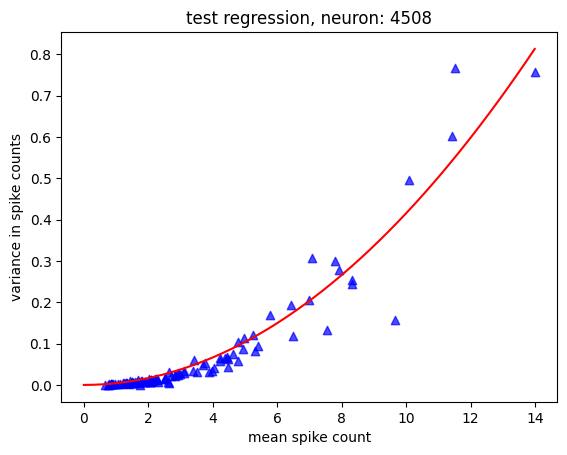

In [37]:
plt.scatter(test_means, test_vars, marker = '^', color = 'b', alpha = 0.7)
plt.plot(np.linspace(0, np.max(means_nonan)), y_pred, color = 'r')
plt.title(f'test regression, neuron: {test_neuron}')
plt.xlabel('mean spike count')
plt.ylabel('variance in spike counts')
plt.show()

# function with regression

In [ ]:
def lineplots_4x4(main_title, neurons, mean_masked, var_masked, savefig = False):
    """
    ADD DOCS
    """
    fig, axes = plt.subplots(4, 4, figsize=(10, 8), sharex=False, sharey=False)
    fig.text(0.5, 1.04, main_title, ha='center', va='top', fontsize=14, fontweight = 'bold', bbox=dict(facecolor='white'))

    for id, neuron in enumerate(neurons):
        i, j = divmod(id, 4)
        ax = axes[i, j]
        
        ax.scatter(mean_masked[..., neuron][:10], var_masked[..., neuron][:10], color = 'black', alpha = 0.5, marker = '.', label = 'predicted response (gray frames)')
        ax.scatter(mean_masked[..., neuron][10:], var_masked[..., neuron][10:], color = 'b', alpha = 0.3, marker = '.', label = 'predicted response (imagenet)')

        # regression
        mask = ~np.isnan(mean_masked[..., neuron])
        x_nonan = mean_masked[..., neuron][mask]
        y_nonan = var_masked[..., neuron][mask]

        params, covariance = curve_fit(smooth_func, x_nonan, y_nonan, maxfev = 10000)
        y_pred = smooth_func(np.linspace(0, np.max(x_nonan), 100), params[0], params[1])
        ax.plot(np.linspace(0, np.max(x_nonan), 100), y_pred, color = 'r', label = 'smooth function regression', alpha = 0.7)
        
        ax.text(0.01, 0.99, f'neuron: {neuron}\nm: {params[0]:.3f}\nb: {params[1]:.3f}', verticalalignment = 'top', horizontalalignment = 'left', 
                transform = ax.transAxes)
        if i == 3: ax.set_xlabel('Mean Predicted\nSpike Count')
        if j == 0: ax.set_ylabel('Variance in\nPredicted Spike Count')

        ax.set_xlim(0, min(np.max(mean_masked)/3, 200)) # how to handle outliers

    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper right', bbox_to_anchor=(1.02, 1.08), ncol=1)    
    plt.tight_layout()
    if savefig: 
        try:
            date = datetime.now()
            file_date = f'({str(date.month)}-{str(date.day)}-{str(date.year)})'
            path_name = f'{main_title}_{file_date}.pdf'
            plt.savefig(os.path.join(os.getcwd(), f'plots//({str(date.month)}-{str(date.day)}-{str(date.year)})', path_name), 
                        bbox_inches = 'tight', pad_inches = 0.3)
        except FileNotFoundError:
            os.makedirs(f'plots//({str(date.month)}-{str(date.day)}-{str(date.year)})', exist_ok = True)
            plt.savefig(os.path.join(os.getcwd(), f'plots//({str(date.month)}-{str(date.day)}-{str(date.year)})', path_name),
                        bbox_inches = 'tight', pad_inches = 0.3)
            plt.close()
    else: 
        plt.show()

*smooth function*
$$
f(x) = \frac{m}{b} \left[ \log(1 + e^{b x}) - \log(2) - \frac{b x}{2} \right]
$$

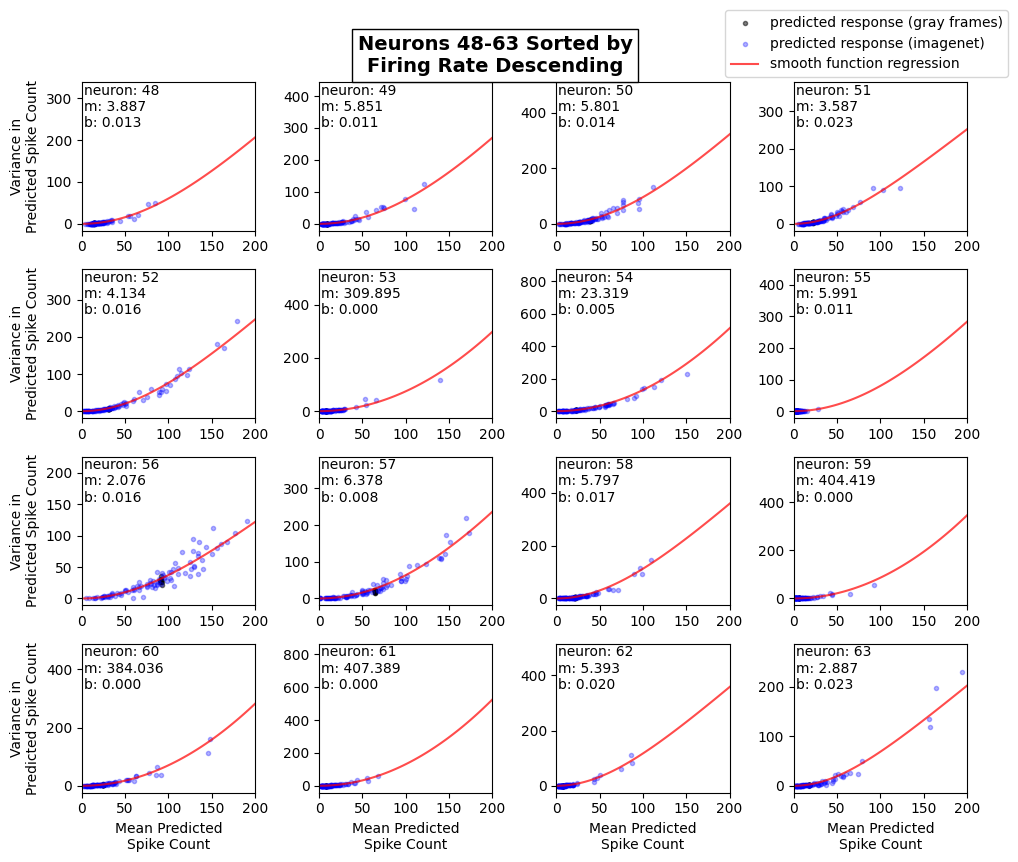

In [51]:
lineplots_4x4('Neurons 48-63 Sorted by\nFiring Rate Descending', [i for i in range(48, 64)], mean_v1_sorted, var_v1_sorted, False)

# fitting different functions

## log(1+exp(bx))

In [30]:
def smooth_func(x, m, b): # used for regression in lineplots_4x4
    return np.log(1 + np.exp(b * x))
    #return (m / b) * (np.log1p(np.exp(b * x)) - np.log(2) - (b * x) / 2) ---original function

In [31]:
def lineplots_4x4(main_title, neurons, mean_masked, var_masked, savefig = False):
    """
    ADD DOCS
    """
    fig, axes = plt.subplots(4, 4, figsize=(10, 8), sharex=False, sharey=False)
    fig.text(0.5, 1.04, main_title, ha='center', va='top', fontsize=14, fontweight = 'bold', bbox=dict(facecolor='white'))

    for id, neuron in enumerate(neurons):
        i, j = divmod(id, 4)
        ax = axes[i, j]
        
        ax.scatter(mean_masked[..., neuron][:10], var_masked[..., neuron][:10], color = 'black', alpha = 0.5, marker = '.', label = 'predicted response (gray frames)')
        ax.scatter(mean_masked[..., neuron][10:], var_masked[..., neuron][10:], color = 'b', alpha = 0.3, marker = '.', label = 'predicted response (imagenet)')
        ax.plot(mean_masked[..., neuron], var_masked[..., neuron], color = 'b', alpha = 0.1)

        # regression
        mask = ~np.isnan(mean_masked[..., neuron])
        x_nonan = mean_masked[..., neuron][mask]
        y_nonan = var_masked[..., neuron][mask]

        params, covariance = curve_fit(smooth_func, x_nonan, y_nonan)
        y_pred = smooth_func(np.linspace(0, np.max(x_nonan)), params[0], params[1])
        ax.plot(np.linspace(0, np.max(x_nonan)), y_pred, color = 'r', label = 'smooth function regression', alpha = 0.7)
        
        ax.text(0.01, 0.99, f'm: {params[0]:.3f}\nb: {params[1]:.3f}', verticalalignment = 'top', horizontalalignment = 'left', 
                transform = ax.transAxes)
        if i == 3: ax.set_xlabel('Mean Predicted\nSpike Count')
        if j == 0: ax.set_ylabel('Variance in\nPredicted Spike Count')

    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper right', bbox_to_anchor=(1.02, 1.08), ncol=1)    
    plt.tight_layout()
    if savefig: 
        try:
            date = datetime.now()
            file_date = f'({str(date.month)}-{str(date.day)}-{str(date.year)})'
            path_name = f'{main_title}_{file_date}.pdf'
            plt.savefig(os.path.join(os.getcwd(), f'plots//({str(date.month)}-{str(date.day)}-{str(date.year)})', path_name), 
                        bbox_inches = 'tight', pad_inches = 0.3)
        except FileNotFoundError:
            os.makedirs(f'plots//({str(date.month)}-{str(date.day)}-{str(date.year)})', exist_ok = True)
            plt.savefig(os.path.join(os.getcwd(), f'plots//({str(date.month)}-{str(date.day)}-{str(date.year)})', path_name),
                        bbox_inches = 'tight', pad_inches = 0.3)
            plt.close()
    else: 
        plt.show()

C:\Users\joshf\AppData\Local\Temp\ipykernel_20536\1169816328.py:21: OptimizeWarning: Covariance of the parameters could not be estimated
  params, covariance = curve_fit(smooth_func, x_nonan, y_nonan)


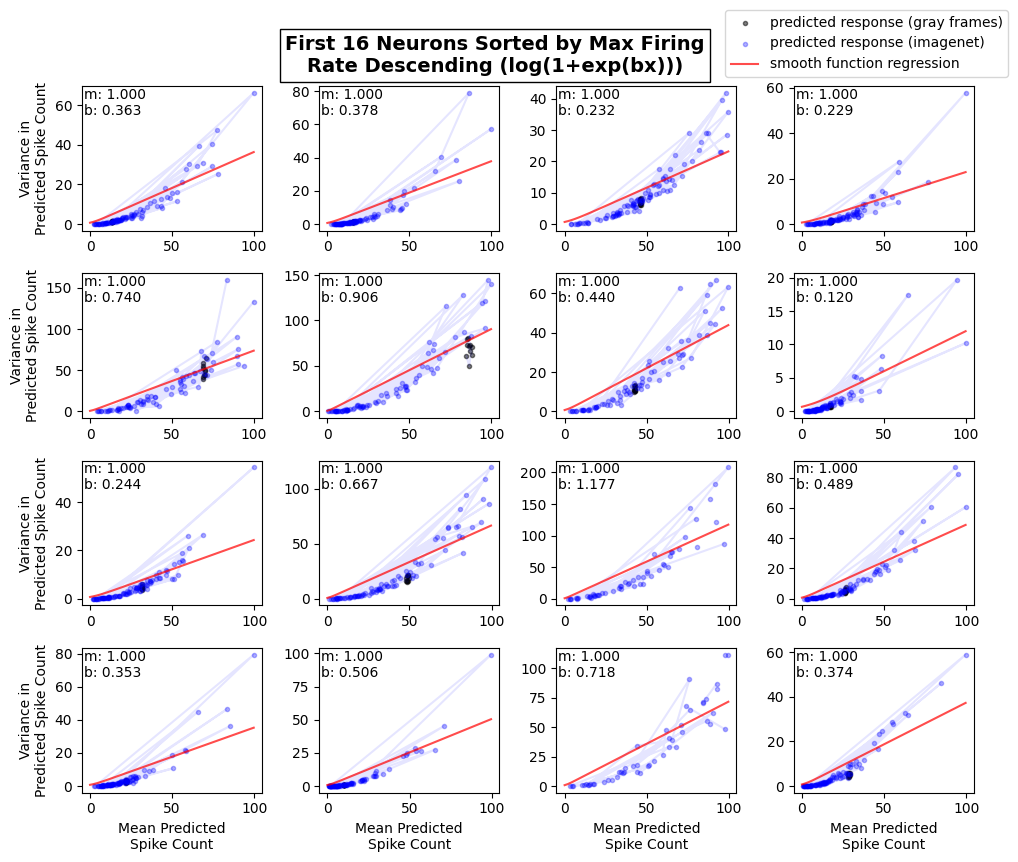

In [32]:
lineplots_4x4('First 16 Neurons Sorted by Max Firing\nRate Descending (log(1+exp(bx)))', [i for i in range(16)], mean_v1_sorted, var_v1_sorted, False)

# plotting regression (top 100 by max. firing rate)

In [23]:
def smooth_func(x, m, b): # used for regression in lineplots_4x4

    """    
    Parameters
    ----------
    x : float or np.ndarray
        Input value(s) along the x-axis
    m : float
        Scaling parameter
    b : float
        Growth rate parameter
    
    Returns
    -------
    float or np.ndarray
        Function value(s) f(x)
    """
    return (m / b) * (np.log1p(np.exp(b * x)) - np.log(2) - (b * x) / 2)

In [56]:
max_arr = [-np.inf]
for neuron in range(100):
    mask = ~np.isnan(mean_v1_sorted[..., neuron])
    x_nonan = mean_v1_sorted[..., neuron][mask]
    if np.nanmax(x_nonan) > np.max(max_arr): max_arr = x_nonan

print('here is our list with largest max\n', max_arr)

here is our list with largest max
 [13.49559033 13.20414376 13.33219379 13.48667654 13.40705301 13.38897346
 13.37947256 13.38479252 13.38145963 13.28629481 99.99202925 43.38157028
  9.26985801 13.43587011 14.86176074  9.875448   21.93988773 14.2592603
 30.46654504 49.00929606  3.32736277 50.10639624 17.56099358 17.31297937
 15.68503766 14.09379771  7.58671759 14.55331819 21.22009202 12.34940197
 15.56333281 68.82803761  5.65679783 26.54057663 13.90238356 16.74646771
  7.80569599 15.97608101  5.05288298 26.61215156 36.34611303 31.96632764
 18.76492426  6.02427951 45.63805877  2.16835165  2.45098057  9.70223738
 19.21312338  7.36123321  3.39032123 28.28332802 24.9848594  66.41173682
 22.44460731 15.42671771 60.19549388 43.18177142 31.00936375 25.61104699
 20.35761719 24.79098884 10.70511056 17.24329856  4.92484922 46.88930941
 27.06182762 15.88757204 43.95212337 25.87364702  7.54925956 34.92091286
 41.08400643 13.12126122 32.01528641  8.54653017  3.91790011 77.84603839
 65.23214002 19.5

In [27]:
def smooth_func(x, m, b): # used for regression in lineplots_4x4

    """    
    Parameters
    ----------
    x : float or np.ndarray
        Input value(s) along the x-axis
    m : float
        Scaling parameter
    b : float
        Growth rate parameter
    
    Returns
    -------
    float or np.ndarray
        Function value(s) f(x)
    """
    return (m / b) * (np.log1p(np.exp(b * x)) - np.log(2) - (b * x) / 2)

C:\Users\joshf\AppData\Local\Temp\ipykernel_87160\1257414031.py:10: OptimizeWarning: Covariance of the parameters could not be estimated
  params, covariance = curve_fit(smooth_func, x_nonan, y_nonan, maxfev = 10000)


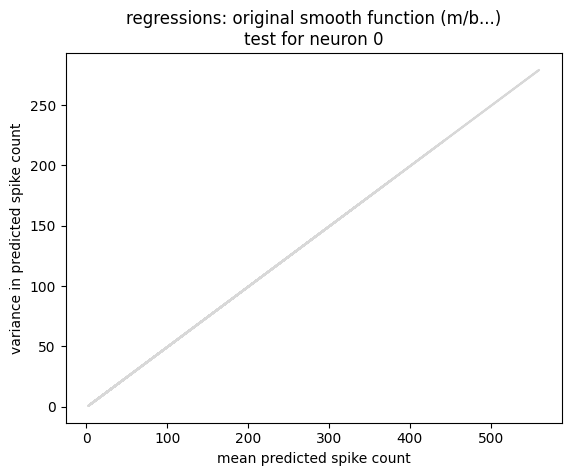

In [28]:
from visualizations import smooth_func
y_preds = []

# assume mean_v1 array is sorted up until this point, shoud always be sorted before calling to this code/function (if made)
for neuron in range(100):
    mask = ~np.isnan(mean_v1_sorted[..., neuron])
    x_nonan = mean_v1_sorted[..., neuron][mask]
    y_nonan = var_v1_sorted[..., neuron][mask]

    params, covariance = curve_fit(smooth_func, x_nonan, y_nonan, maxfev = 10000)
    #y_pred = smooth_func(np.linspace(0, np.max(x_nonan), 100), params[0], params[1])
    y_pred = smooth_func(max_arr, params[0], params[1]) # now change to predict on list with largest values

    y_preds.append(y_pred)

for neuron in range(1):
    y = y_preds[neuron]
    plt.plot(max_arr, y, color = 'gray', alpha=0.3)

plt.title('regressions: original smooth function (m/b...)\ntest for neuron 0')
plt.ylabel('variance in predicted spike count')
plt.xlabel('mean predicted spike count')
plt.show()

which plot is better, the one above or below that uses a linspace

C:\Users\joshf\AppData\Local\Temp\ipykernel_87160\1136232806.py:9: OptimizeWarning: Covariance of the parameters could not be estimated
  params, covariance = curve_fit(smooth_func, x_nonan, y_nonan, maxfev = 10000)


ValueError: x and y must have same first dimension, but have shapes (108,) and (100,)

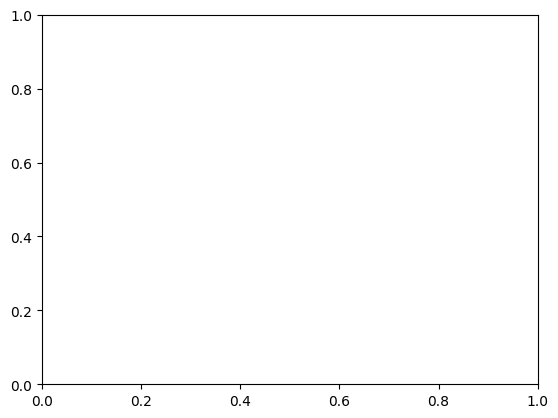

In [29]:
y_preds = []

# assume mean_v1 array is sorted up until this point, shoud always be sorted before calling to this code/function (if made)
for neuron in range(100):
    mask = ~np.isnan(mean_v1_sorted[..., neuron])
    x_nonan = mean_v1_sorted[..., neuron][mask]
    y_nonan = var_v1_sorted[..., neuron][mask]

    params, covariance = curve_fit(smooth_func, x_nonan, y_nonan, maxfev = 10000)
    #y_pred = smooth_func(np.linspace(0, np.max(x_nonan), 100), params[0], params[1])
    y_pred = smooth_func(np.linspace(0, np.max(max_arr), 100), params[0], params[1]) # now change to predict on list with largest values

    y_preds.append(y_pred)

for neuron in range(1):
    y = y_preds[neuron]
    plt.plot(np.linspace(0, np.max(max_arr), 108), y, color = 'gray', alpha=0.3)

plt.title('regressions: original smooth function (m/b...)\ntest for neuron 0')
plt.ylabel('variance in predicted spike count')
plt.xlabel('mean predicted spike count')
plt.show()

C:\Users\joshf\AppData\Local\Temp\ipykernel_87160\2675707414.py:9: OptimizeWarning: Covariance of the parameters could not be estimated
  params, covariance = curve_fit(smooth_func, x_nonan, y_nonan, maxfev = 10000)


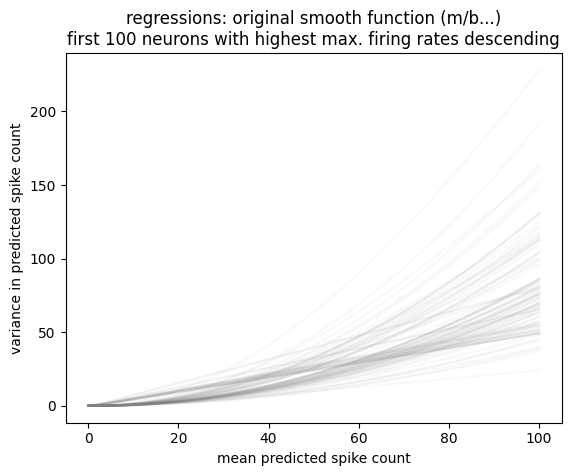

In [30]:
y_preds = []

# assume mean_v1 array is sorted up until this point, shoud always be sorted before calling to this code/function (if made)
for neuron in range(100):
    mask = ~np.isnan(mean_v1_sorted[..., neuron])
    x_nonan = mean_v1_sorted[..., neuron][mask]
    y_nonan = var_v1_sorted[..., neuron][mask]

    params, covariance = curve_fit(smooth_func, x_nonan, y_nonan, maxfev = 10000)
    #y_pred = smooth_func(np.linspace(0, np.max(x_nonan), 100), params[0], params[1])
    #y_pred = smooth_func(np.linspace(0, np.max(max_arr), 108), params[0], params[1]) # now change to predict on list with largest values
    y_pred = smooth_func(np.linspace(0, 100, 100), params[0], params[1])

    y_preds.append(y_pred)

for neuron in range(100):
    y = y_preds[neuron]
    plt.plot(np.linspace(0, 100, 100), y, color = 'gray', alpha=0.05)

plt.title('regressions: original smooth function (m/b...)\nfirst 100 neurons with highest max. firing rates descending')
plt.ylabel('variance in predicted spike count')
plt.xlabel('mean predicted spike count')
plt.show()

In [33]:
lst = [i for i in range(100)]
lsts = []
for i in range(10):
    lsts.append(lst)

In [34]:
len(lsts)

10

In [37]:
test_mean = np.mean(lsts, axis = 0)

In [39]:
len(test_mean)

100

list of random neuron
 [1656    3 1744  500 4649 1740 1178 1995  650 3653 2056 2880 1076 2667
 3145 2879  846 1935 2118 1536 1655 5017  625 1910  776 2547 3894 5105
 3494 2555 5294 3085 5080 2899 4917 4455  950 3737 2004 1528 4966 4537
 4354  194 2932 3247 2425  206 5007 1640 2383 4657 1707  567  477 2179
 3179 4514 3688 1648 4380 3654  670 3979  942 1194 3431   99 2063 3220
 4074 3457  873 1605 1011 4082 4681 3339 3712 2618 3263 1453 2963 3614
 1766 3782 2444 4415 1202 2009 3159 1087 4544 1719 2661  683 5170 2960
  242 2019 2250 4013 1379 4208 2904  547 1088 1048 4183 1674 1048 4906
 4275 5259  413 3485 2494 1255 2315 1884 1873   73 5209 4566 5133 4744
 4787  886 3406 3452 3986 1420 3907 3426 4849 1336  116  105  637    3
 3290  125  624 3167 2870  643 5039 1477 5102 3680 3383 2773 1019 4880
 1982 4531 2501 4343 1746 4978 2706 4867 3647  584  671   19 4438 3331
 5294  633 4026 1641 4900 2278  820 4201  833 2985 2177 5033 2906 2512
 1387 3870  912 4159 3776 1853 1050 2389 3082 4544 155

c:\Users\joshf\OneDrive\GitHub\fnn-haefner\visualizations.py:780: RuntimeWarning: overflow encountered in exp
  return (m / b) * (np.log1p(np.exp(b * x)) - np.log(2) - (b * x) / 2)
C:\Users\joshf\AppData\Local\Temp\ipykernel_87160\10548940.py:12: OptimizeWarning: Covariance of the parameters could not be estimated
  params, covariance = curve_fit(smooth_func, x_nonan, y_nonan, maxfev = 10000)


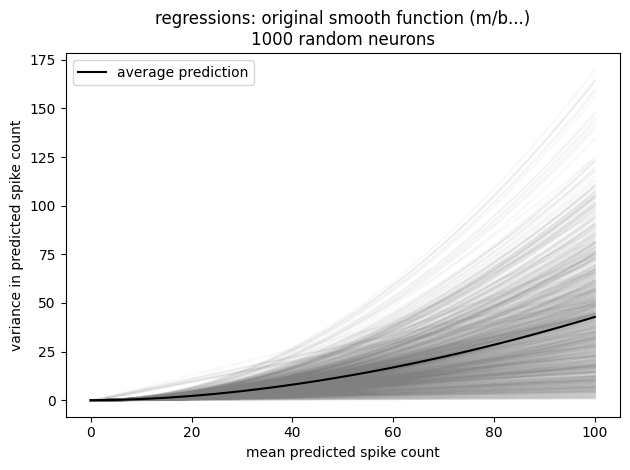

In [40]:
y_preds = []
random_neurons = np.random.randint(0, mean_v1_sorted.shape[1], 1000)

print('list of random neuron\n', random_neurons)

# assume mean_v1 array is sorted up until this point, shoud always be sorted before calling to this code/function (if made)
for neuron in random_neurons:
    mask = ~np.isnan(mean_v1_sorted[..., neuron])
    x_nonan = mean_v1_sorted[..., neuron][mask]
    y_nonan = var_v1_sorted[..., neuron][mask]

    params, covariance = curve_fit(smooth_func, x_nonan, y_nonan, maxfev = 10000)
    #y_pred = smooth_func(np.linspace(0, np.max(x_nonan), 100), params[0], params[1]) # now change to predict on list with largest values
    y_pred = smooth_func(np.linspace(0, 100, 100), params[0], params[1]) 

    y_preds.append(y_pred)

for neuron in range(len(random_neurons)):
    y = y_preds[neuron]
    plt.plot(np.linspace(0, 100, 100), y, color = 'gray', alpha=0.05)

y_pred_avg = np.mean(y_preds, axis=0)
plt.plot(np.linspace(0, 100, 100), y_pred_avg, color = 'black', label = 'average prediction')
plt.legend()
plt.title('regressions: original smooth function (m/b...)\n1000 random neurons')
plt.ylabel('variance in predicted spike count')
plt.xlabel('mean predicted spike count')
plt.tight_layout()
plt.show()

*smooth function*
$$
f(x) = \frac{m}{b} \left[ \log(1 + e^{b x}) - \log(2) - \frac{b x}{2} \right]
$$

# plotting regressions (all neurons)

In [42]:
def smooth_func(x, m, b): # used for regression in lineplots_4x4

    """    
    Parameters
    ----------
    x : float or np.ndarray
        Input value(s) along the x-axis
    m : float
        Scaling parameter
    b : float
        Growth rate parameter
    
    Returns
    -------
    float or np.ndarray
        Function value(s) f(x)
    """
    return (m / b) * (np.log1p(np.exp(b * x)) - np.log(2) - (b * x) / 2)

In [43]:
neuron = 0 # test with neuron 0

# regression
mask = ~np.isnan(mean_v1_sorted[..., neuron])
x_nonan = mean_v1_sorted[..., neuron][mask]
y_nonan = var_v1_sorted[..., neuron][mask]

params, covariance = curve_fit(smooth_func, x_nonan, y_nonan)
y_pred = smooth_func(np.linspace(0, np.max(x_nonan), 100), params[0], params[1])


C:\Users\joshf\AppData\Local\Temp\ipykernel_87160\3390284638.py:18: RuntimeWarning: overflow encountered in exp
  return (m / b) * (np.log1p(np.exp(b * x)) - np.log(2) - (b * x) / 2)
C:\Users\joshf\AppData\Local\Temp\ipykernel_87160\2922230504.py:8: OptimizeWarning: Covariance of the parameters could not be estimated
  params, covariance = curve_fit(smooth_func, x_nonan, y_nonan)


In [75]:
print('len x nonan:', len(x_nonan))
print('len y nonan:', len(y_nonan))

len x nonan: 108
len y nonan: 108


In [76]:
len(y_pred)

100

In [77]:
mean_v1_sorted.shape

(110, 5312)

issue here is that it seems the x axis has to default to array with smallest x since those with larger x do not encompass the same range of values. fix: find the array with largest x and predict based on that 

In [78]:
max_arr = [-np.inf]
for neuron in range(mean_v1_sorted.shape[1]):
    mask = ~np.isnan(mean_v1_sorted[..., neuron])
    x_nonan = mean_v1_sorted[..., neuron][mask]
    if np.nanmax(x_nonan) > np.max(max_arr): max_arr = x_nonan

print('here is our list with largest max\n', max_arr)

here is our list with largest max
 [13.49559033 13.20414376 13.33219379 13.48667654 13.40705301 13.38897346
 13.37947256 13.38479252 13.38145963 13.28629481 99.99202925 43.38157028
  9.26985801 13.43587011 14.86176074  9.875448   21.93988773 14.2592603
 30.46654504 49.00929606  3.32736277 50.10639624 17.56099358 17.31297937
 15.68503766 14.09379771  7.58671759 14.55331819 21.22009202 12.34940197
 15.56333281 68.82803761  5.65679783 26.54057663 13.90238356 16.74646771
  7.80569599 15.97608101  5.05288298 26.61215156 36.34611303 31.96632764
 18.76492426  6.02427951 45.63805877  2.16835165  2.45098057  9.70223738
 19.21312338  7.36123321  3.39032123 28.28332802 24.9848594  66.41173682
 22.44460731 15.42671771 60.19549388 43.18177142 31.00936375 25.61104699
 20.35761719 24.79098884 10.70511056 17.24329856  4.92484922 46.88930941
 27.06182762 15.88757204 43.95212337 25.87364702  7.54925956 34.92091286
 41.08400643 13.12126122 32.01528641  8.54653017  3.91790011 77.84603839
 65.23214002 19.5

In [44]:
y_preds = []

for neuron in range(mean_v1_sorted.shape[1]):
    mask = ~np.isnan(mean_v1_sorted[..., neuron])
    x_nonan = mean_v1_sorted[..., neuron][mask]
    y_nonan = var_v1_sorted[..., neuron][mask]

    params, covariance = curve_fit(smooth_func, x_nonan, y_nonan, maxfev = 10000)
    #y_pred = smooth_func(np.linspace(0, np.max(x_nonan), 100), params[0], params[1])
    y_pred = smooth_func(np.linspace(0,100,100), params[0], params[1]) # now change to predict on list with largest values

    y_preds.append(y_pred)

C:\Users\joshf\AppData\Local\Temp\ipykernel_87160\3390284638.py:18: RuntimeWarning: overflow encountered in exp
  return (m / b) * (np.log1p(np.exp(b * x)) - np.log(2) - (b * x) / 2)
C:\Users\joshf\AppData\Local\Temp\ipykernel_87160\2318321024.py:8: OptimizeWarning: Covariance of the parameters could not be estimated
  params, covariance = curve_fit(smooth_func, x_nonan, y_nonan, maxfev = 10000)


In [80]:
print('len y preds:', len(y_preds[0]))

len y preds: 108


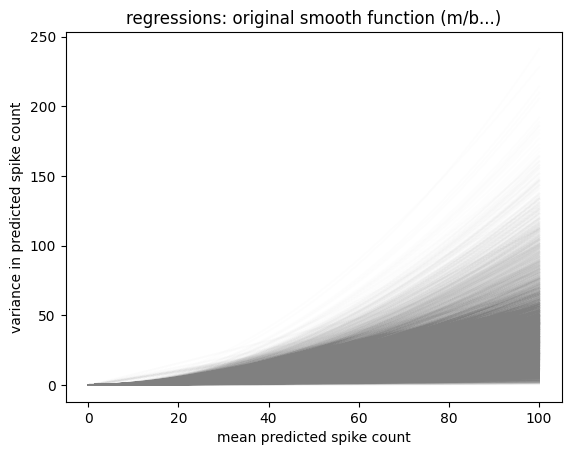

In [45]:
for neuron in range(len(y_preds)):
    y = y_preds[neuron]
    plt.plot(np.linspace(0,100,100), y, color = 'gray', alpha=0.01)

plt.title('regressions: original smooth function (m/b...)')
plt.ylabel('variance in predicted spike count')
plt.xlabel('mean predicted spike count')
plt.show()

# plotting tangent line slopes at x=100

In [58]:
x, m, b = sympy.symbols('x m b')

In [60]:
func_expr = (m / b) * (sympy.log(1 + sympy.exp(b * x)) - sympy.log(2) - (b * x) / 2)

In [ ]:
f_prime = sympy.diff(func_expr, x) # get derivative

In [66]:
print('derivative\n----------')
f_prime

derivative
----------


m*(-b/2 + b*exp(b*x)/(exp(b*x) + 1))/b

In [73]:
simplified_func = sympy.simplify(f_prime)
print("simplified f'")
simplified_func

simplified f'


m*tanh(b*x/2)/2

In [67]:
y_preds = []
params_list = []
for neuron in range(mean_v1_sorted.shape[1]):
    mask = ~np.isnan(mean_v1_sorted[..., neuron])
    x_nonan = mean_v1_sorted[..., neuron][mask]
    y_nonan = var_v1_sorted[..., neuron][mask]

    params, covariance = curve_fit(smooth_func, x_nonan, y_nonan, maxfev = 10000)
    y_pred = smooth_func(np.linspace(0,100,100), params[0], params[1]) 
    params_list.append(params)
    y_preds.append(y_pred)

C:\Users\joshf\AppData\Local\Temp\ipykernel_87160\1954758462.py:2: RuntimeWarning: overflow encountered in exp
  return (m / b) * (np.log1p(np.exp(b * x)) - np.log(2) - (b * x) / 2)
C:\Users\joshf\AppData\Local\Temp\ipykernel_87160\2678682947.py:8: OptimizeWarning: Covariance of the parameters could not be estimated
  params, covariance = curve_fit(smooth_func, x_nonan, y_nonan, maxfev = 10000)


In [68]:
print(len(params_list))

5312


get slope at x=100

In [87]:
test = simplified_func.subs({x: 1, m: 2, b: 3})
test

tanh(3/2)

In [88]:
test_simplified = test.evalf()
test_simplified

0.905148253644866

two figures, slope as function of max and mean firing rate

In [92]:
slopes_list = []
for neuron in range(mean_v1_sorted.shape[1]):
    slope = simplified_func.subs({x: 100, m: params_list[neuron][0], b: params_list[neuron][1]}) # eval at x=100
    slopes_list.append(slope)

In [95]:
len(slopes_list)

5312

In [1]:
mean_v1_sorted.shape

NameError: name 'mean_v1_sorted' is not defined

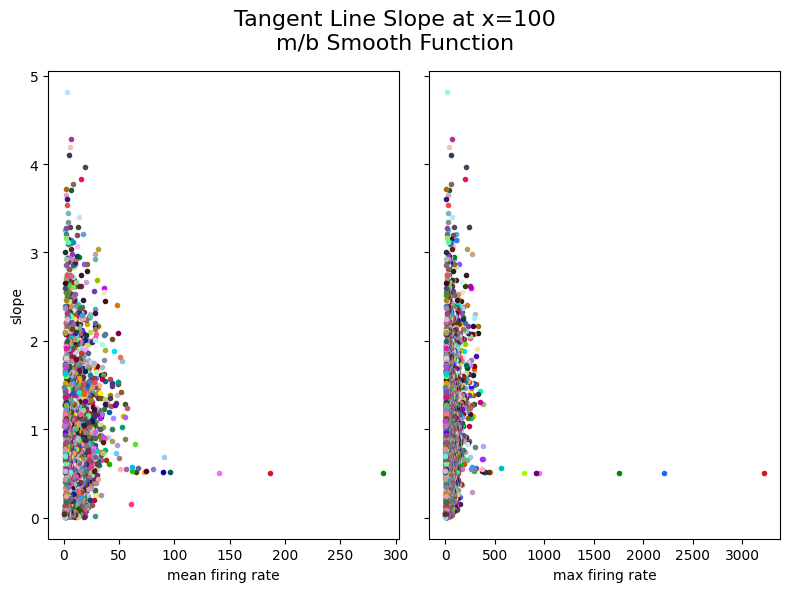

In [109]:
fig, axes = plt.subplots(1, 2, sharey = True, figsize = (8,6))

glasbey_palette = glasbey.create_palette(palette_size=mean_v1_sorted.shape[1])

# plot slope as function of MEAN firing rate
for neuron in range(mean_v1_sorted.shape[1]):
    y = slopes_list[neuron]
    color = glasbey_palette[neuron]

    x = np.mean(mean_v1_sorted[..., neuron])
    axes[0].scatter(x, y, color = color, marker = '.')
    axes[0].set_xlabel('mean firing rate')
    axes[0].set_ylabel('slope')
# plot slope as function of MAX firing rate
    x = np.max(mean_v1_sorted[..., neuron])
    axes[1].scatter(x, y, color = color, marker = '.')
    axes[1].set_xlabel('max firing rate')

fig.suptitle('Tangent Line Slope at x=100\nm/b Smooth Function', fontsize=16)
plt.tight_layout()
plt.show()

two figures, one for m and one for b

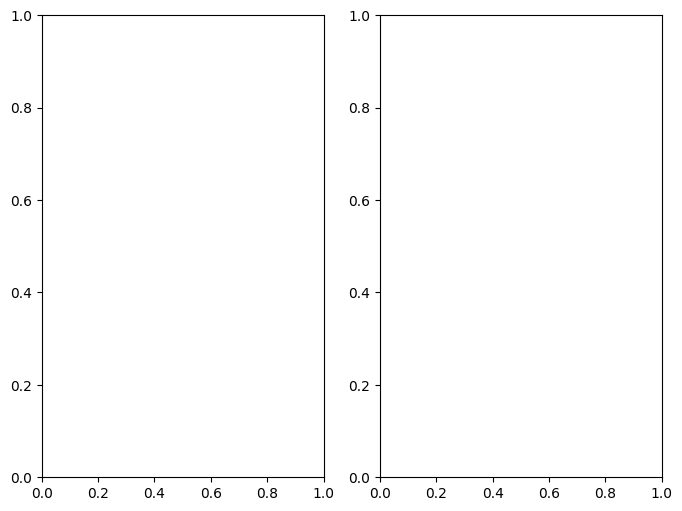

In [ ]:
fig, axes = plt.subplots(1, 2, figsize = (8,6))

